# **Simulación de Caminatas Aleatorias**
## 1. Fundamentos teóricos
Una caminata aleatoria unidimensional es un proceso estocástico que describe una ruta que consiste en una sucesión de pasos aleatorios en el espacio de los números enteros.

*Definición:*

Mar$X_i$ una variable aleatoria que representa el paso en el instante $i$, tal que: $X_i = 1$ con probabilidad $p$(movimiento a la derecha). $X_i = -1 $ con probabilidad $q = 1 - p$( movimiento a la izquierda).

La posición $S_n$ después de $n$ pasos se define como la suma de los pasos individuales:
$$S_n = \sum_{i=1}^{n} X_i$$**Propiedades Estadísticas**

**Valor esperado:** El promedio de la posición final tras muchos experimentos es:
$$E[S_n] = n(p - q) = n(2p - 1)$$**Varianza:** Mide la dispersión de las trayectorias:
$$Var(S_n) = 4np(1 - p)$$

# 2. Implementación en Python
A continuación, se define la función que permite simular este fenómeno.

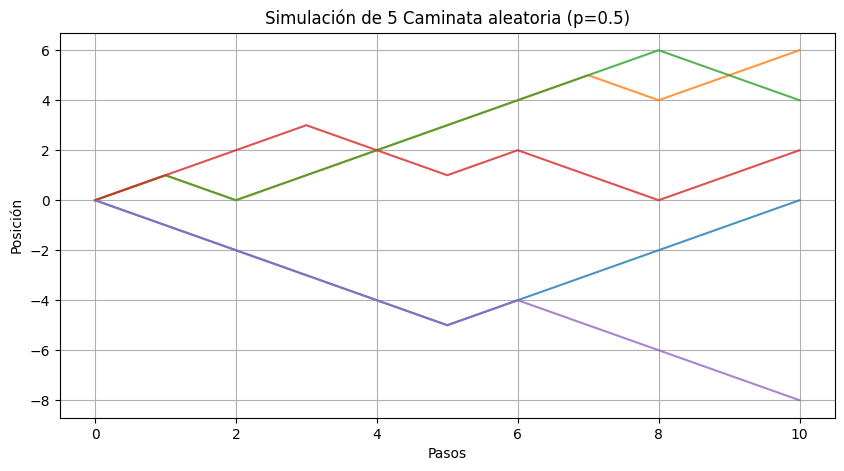

MATRIZ DE TRAYECTORIAS
[[ 0 -1 -2 -3 -4 -5 -4 -3 -2 -1  0]
 [ 0  1  0  1  2  3  4  5  4  5  6]
 [ 0  1  0  1  2  3  4  5  6  5  4]
 [ 0  1  2  3  2  1  2  1  0  1  2]
 [ 0 -1 -2 -3 -4 -5 -4 -5 -6 -7 -8]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define la función principal con parámetros:
# p: probabilidad de subir, pasos: duración, caminatas: cuántas simulaciones hacer
def simular_caminata(p=0.5, pasos=10, caminatas=5):
    trayectorias = [] # Crea una lista vacía para almacenar el historial de cada caminata

    plt.figure(figsize=(10, 5)) # Crea una ventana para el gráfico

    for i in range(caminatas): # Inicia un bucle para realizar el número de simulaciones pedidas
        posicion = [0] # Cada caminata comienza siempre en el punto 0

        for j in range(pasos): # Inicia un bucle para cada paso individual dentro de una caminata
            #genera un número decimal entre 0 y 1
            if np.random.random() < p:
                posicion.append(posicion[-1] + 1) # Si es menor a 'p', sube (+1 a la última posición)
            else:
                posicion.append(posicion[-1] - 1) # Si no, baja (-1 a la última posición)

        trayectorias.append(posicion)
        plt.plot(posicion, alpha=0.8)

    plt.title(f"Simulación de {caminatas} Caminata aleatoria (p={p})")
    plt.xlabel('Pasos')
    plt.ylabel('Posición')
    plt.grid(True)
    plt.show()

    return np.array(trayectorias)

# Ejecución
datos = simular_caminata()
print("MATRIZ DE TRAYECTORIAS")
print(datos)

# Analisis
 A través de la experimentación con la función, podemos observar comportamientos específicos según los valores de entrada:

## Dirección y Tendencia.

La dirección de la caminata está gobernada por el valor de $p$: Si $p > 0.5$: La caminata tiene una tendencia alcista . Mientras más grande sea $p$(por ejemplo,$0.9$), es más probable que cada paso sea hacia la derecha ($+1$), resultando en trayectorias que suben casi linealmente.

Si$p < 0.5$: La caminata tiene una tendencia bajista . El proceso se aleja del origen hacia valores negativos.

Si$p = 0.5$: Se denomina Caminata Aleatoria Simétrica . No hay una dirección preferencial; el proceso es "justo" y fluctúa alrededor del cero.

#El Regreso al Origen

**¿Qué debe pasar para que el proceso regrese al cero?**

En una caminata simétrica ($p = 0.5$) la probabilidad de regresar al origen es 1 (es decir, tarde o temprano regresará con total certeza).

En una caminata sesgada ($p \neq 0.5$): Si existe una tendencia (por ejemplo  $p=0.7$), la probabilidad de regresar al origen es menor a 1. El proceso "escapa" hacia el infinito y es posible que nunca vuelva a tocar el cero.

**¿Cuánto tarda en regresar?**

En el caso simétrico ($p=0.5$), aunque el regreso es seguro, el tiempo esperado de retorno es infinito . Esto significa que algunas trayectorias regresan rápido, pero otras pueden alejarse tanto que tardan una cantidad de pasos inmensa en volver.

#¿Cuántas veces regresó al origen (cero)?
Para saber si una trayectoria tocó el cero después de empezar, buscamos el valor 0 en la lista (excluyendo el primer paso).

In [ ]:

# Revisamos si hay algún 0 en la matriz después de la columna inicial
regresos = 0
for fila in datos:
    if 0 in fila[1:]: # El primer 0 es el inicio, buscamos a partir del paso 1
        regresos += 1
print(f"Caminatas que regresaron al origen: {regresos} de {len(datos)}")

Caminatas que regresaron al origen: 4 de 5


#Máximo Alejamiento Absoluto
Mientras que la posición final solo nos dice dónde terminó la posicion, el máximo alejamiento captura el punto más extremo alcanzado en cualquier momento de la trayectoria, sin importar si fue en dirección positiva o negativa.

In [ ]:
#Máximo alejamiento absoluto
# Buscamos el valor más grande (positivo o negativo) en toda la matriz
max_alejamiento = np.max(np.abs(datos))
print(f"Máximo alejamiento del origen alcanzado: {max_alejamiento}")

Máximo alejamiento del origen alcanzado: 8


Relación con el Tiempo ($n$): En una caminata aleatoria, la distancia máxima esperada no crece de forma lineal con los pasos, sino que está relacionada con la raíz cuadrada del número de pasos ($\sqrt{n}$). Por ejemplo, en 100 pasos, es muy probable ver alejamientos cercanos a 10.

El máximo alejamiento es un indicador de la volatilidad del proceso. Nos permite entender que, aunque el promedio sea cercano a cero, las trayectorias individuales tienen la capacidad de explorar zonas muy alejadas del origen.

#Visualización de la Trayectoria y Punto Promedio
Este apartado permite observar cómo se comporta el grupo de caminatas en su conjunto a través del tiempo. Mientras las trayectorias individuales fluctúan.

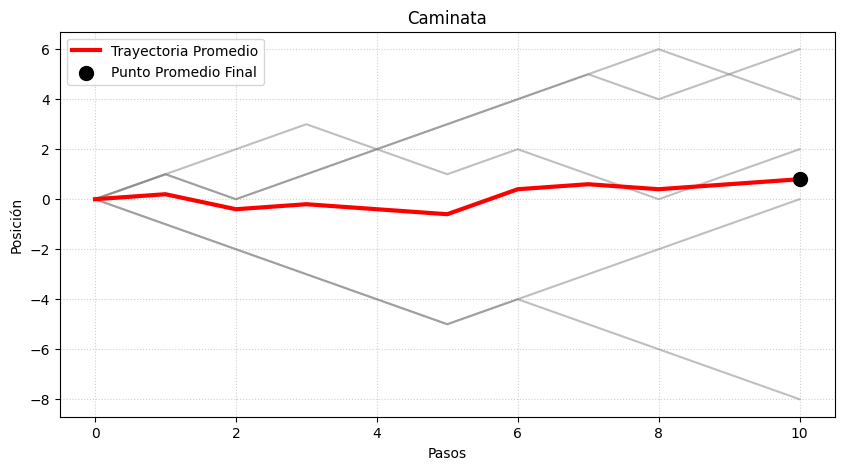

In [ ]:
# 1. Calculamos el promedio de todas las caminatas para cada paso del tiempo
promedio_paso_a_paso = np.mean(datos, axis=0)
posicion_final_media = promedio_paso_a_paso[-1]

plt.figure(figsize=(10, 5))

for caminata in datos:
    plt.plot(caminata, alpha=0.5, color='gray') # Gris tenue para el fondo

# 3. Graficamos la línea de tendencia (Trayectoria Promedio)
plt.plot(promedio_paso_a_paso, color='red', linewidth=3, label='Trayectoria Promedio')

# 4. Marcamos el punto exacto donde termina el promedio
plt.scatter(len(promedio_paso_a_paso)-1, posicion_final_media, color='black', s=100, zorder=5, label='Punto Promedio Final')

plt.title(f"Caminata")
plt.xlabel('Pasos')
plt.ylabel('Posición')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Al ver las líneas grises (individuales) junto a la línea roja (promedio), se nota que aunque algunas partículas se alejan mucho, el "centro" del grupo se mantiene estable.

La Línea Roja (Trayectoria Media): Esta línea suaviza las variaciones extremas. Si la probabilidad  $p$  es  $0.5$  , verás que la línea roja es casi horizontal, pegada al cero.

El Punto Negro: Representa el valor final esperado. Es el resumen numérico de todo el experimento; nos dice dónde encontraríamos el promedio de todas las partículas si lanzáramos miles de ellas.

#Posición Final Promedio
Este cálculo busca determinar el "centro" de todas las trayectorias al concluir el número total de pasos. Es la prueba ácida para verificar si existe un sesgo en nuestra simulación.

#Conclusion

Lo más interesante de este ejercicio es ver cómo el caos de cada caminata individual se "doma" cuando las miras todas juntas. Aunque al principio parece que cada línea va por su cuenta sin ningún orden, la línea roja del promedio nos demuestra que el azar no es tan loco como parece: siempre termina obedeciendo a la probabilidad que configuramos al inicio. Si $p$ es 0.5, el grupo se mantiene centrado; pero en cuanto mueves ese valor, la matriz de datos nos muestra cómo la partícula es empujada casi a la fuerza hacia una dirección, haciendo que volver al cero sea casi imposible.

 Al final, el uso de la matriz y el análisis numérico nos permite ver que la estadística es, en realidad, el lenguaje que le da sentido al desorden. Es la prueba de que, aunque no podamos adivinar el camino de una sola partícula, sí podemos predecir con mucha precisión hacia dónde irá la multitud.